In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import mlflow
import joblib

In [2]:
# columns: CustomerID, Genre, Age, Annual_Income (k$), Spending_Score (1-100)
X_sim = np.array(
    [
        [15, 39],
        [17, 35],
        [18, 92],
        [20, 95],
        [23, 75],
        [78, 7],
        [75, 12],
        [77, 20],
        [79, 3],
        [40, 40],
        [42, 52],
        [45, 35],
        [55, 60],
        [58, 58],
    ]
)

df = pd.DataFrame(X_sim)
df = df.rename(columns={0: "Annual_Income", 1: "Spending_Score"})
df

,Annual_Income,Spending_Score
0,15,39
1,17,35
2,18,92
3,20,95
4,23,75
5,78,7
6,75,12
7,77,20
8,79,3
9,40,40


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sim)

print("Standardized data (excerpt):")
df_scaled = pd.DataFrame(X_scaled)
df_scaled = df_scaled.rename(columns={0: "Annual_Income", 1: "Spending_Score"})
df_scaled.head()

Standardized data (excerpt):


,Annual_Income,Spending_Score
0,-1.292163,-0.194181
1,-1.208412,-0.335404
2,-1.166536,1.677022
3,-1.082785,1.782939
4,-0.957158,1.076825


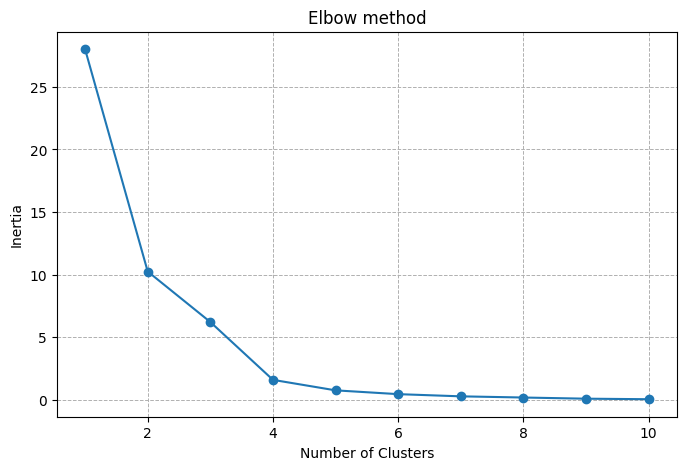

In [4]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.grid(True, ls="--", lw=0.7)
plt.show()

In [5]:
K_optimal = 5

kmeans_final = KMeans(n_clusters=K_optimal, random_state=42)
kmeans_final.fit(X_scaled)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [6]:
labels = kmeans_final.predict(X_scaled)
silhouette_svg = silhouette_score(X_scaled, labels)

print(f"Silhouette Coefficient for K={K_optimal}: {silhouette_svg:.4f}")

Silhouette Coefficient for K=5: 0.7213


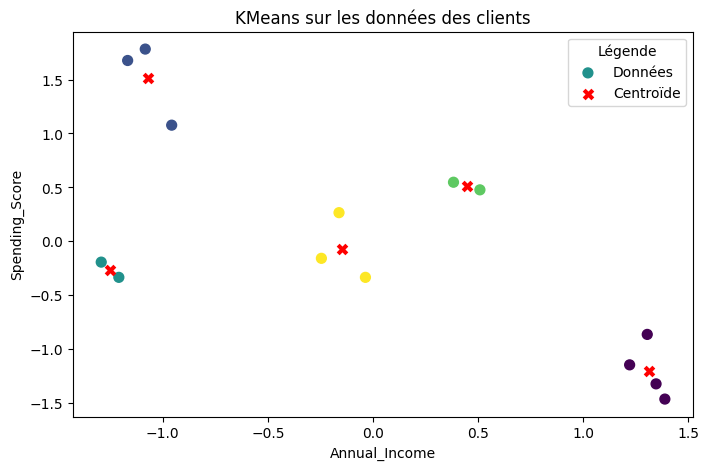

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap="viridis", s=50, label="Données"
)
plt.scatter(
    kmeans_final.cluster_centers_[:, 0],
    kmeans_final.cluster_centers_[:, 1],
    c="red",
    s=70,
    marker="X",
    label="Centroïde",
    lw=0,
)
plt.xlabel("Annual_Income")
plt.ylabel("Spending_Score")
plt.legend(title="Légende")
plt.title("KMeans sur les données des clients")
plt.show()

In [18]:
mlflow.set_experiment("Clustering")


def track_clustering_run(X_data, k, run_name):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_data)

    score_silhouette = silhouette_score(X_data, labels)
    inertia_value = kmeans.inertia_

    with mlflow.start_run(run_name=run_name):
        # 1. Logging Hyperparameters
        mlflow.log_param("K", k)
        mlflow.log_param("Algorithm", "KMeans")

        # 2. Logging Metrics
        mlflow.log_metric("Inertia", inertia_value)
        mlflow.log_metric("Silhouette_Score", float(score_silhouette))

        # 3. Logging Artifact (Centroids)
        joblib.dump(kmeans, "kmeans_model.pkl")
        mlflow.log_artifact("kmeans_model.pkl")


track_clustering_run(X_scaled, 3, "KMeans_K3_Initial")
track_clustering_run(X_scaled, 4, "KMeans_K4_Alternative")
print("MLflow tracking of K-Means experiments finished.")

2026/03/21 00:11:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/21 00:11:47 INFO mlflow.store.db.utils: Updating database tables
2026/03/21 00:11:47 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/21 00:11:47 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/03/21 00:11:47 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/21 00:11:47 INFO alembic.runtime.migration: Will assume non-transactional DDL.


MLflow tracking of K-Means experiments finished.
